# Diskrete Filter
Lineare diskrete Filter lassen sich in zwei Gruppen einteilen: FIR- und IIR-Filter. Beide werden im Folgenden erklärt.

## FIR-Filter mit endlicher Impulsantwort
FIR-Filter (Finite Impulse Response) können verwendet werden, um ein Eingangssignal $x(n)$ mit einem Tiefpass (LP), einem Bandpass (BP) oder einem Hochpass (HP) zu filtern. Der FIR-Filter ist durch seine Impulsantwort $h(n)$ definiert. Der Ausgang $y(n)$ des FIR-Filters kann über die Faltung berechnet werden:

$y(n) = x(n)*h(n)=\sum_{m=0}^{M-1} h(m)\cdot x(n-m)$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
sys.path.insert(1, '../Basics')
import WaveFileHandling

r = 48000

x = np.arange(1000)
h = np.arange(100)**0.99
t1 = time.time()
y1 = np.convolve(x, h)
t2 = time.time()
print('Faltung mit np.convolve dauerte {:.6f} Sekunden'.format(t2 - t1))
t1 = time.time()
y2 = np.zeros((x.shape[0] + h.shape[0] - 1,))
for n in range(y2.shape[0]):
    for m in range(h.shape[0]):
        if (n-m >= 0) and (n-m < x.shape[0]):
            y2[n] += x[n-m] * h[m]
t2 = time.time()
print('Faltung mit verschachtelten Schleifen dauerte {:.6f} Sekunden'.format(t2 - t1))
assert np.allclose(y1, y2), 'Die Ergebnisse beider Methoden sollten identisch sein'

Faltung mit np.convolve dauerte 0.000083 Sekunden
Faltung mit verschachtelten Schleifen dauerte 0.064368 Sekunden


## FIR: Schnelle Faltung mittels DFT
Die Faltung im Zeitbereich entspricht einer Multiplikation im Frequenzbereich:

$y(t)=h(t)*x(t) \iff Y(f)=H(f)\cdot X(f)$ mit der Fourier-Transformation

$Y(f)=\int_{-\infty}^\infty y(t)\cdot e^{-j2\pi ft} dt$ für alle drei Signale/Impulsantworten $y(t)$, $x(t)$ und $h(t)$.

Eine Multiplikation ist deutlich schneller als die verschachtelten Schleifen, die zur Auswertung der Faltung notwendig sind. Daher wird im Folgenden ein Algorithmus vorgestellt, mit dem das Faltungsergebnis über die [DFT](../Week03_DiscreteFourierTransform/01_DiscreteFourierTransform.ipynb) berechnet werden kann:

In [2]:
H = np.fft.fft(h, n=y1.shape[0])
X = np.fft.fft(x, n=y1.shape[0])
Y3 = H * X
y3 = np.fft.ifft(Y3).real
assert np.allclose(y1, y3), 'Die Ergebnisse beider Methoden sollten identisch sein'

## FIR: Tiefpass
Ein einfacher Tiefpass mit der Grenzfrequenz $f_c$ ist definiert durch:

$h_\text{lowpass}(n)=\frac{\sin\left(2\pi f_c n/r\right)}{2\pi f_c n/r}\cdot w(n)$

mit dem Hann-Fenster

$w(n)=\frac{1}{2}\left(1+\cos\left(2\pi n / N \right)\right)\cdot\text{rect}\left(\frac{n}{N}\right)$.

Das Hann-Fenster wird durch das rect-Signal auf den Bereich $-\frac{N}{2}< n < \frac{N}{2}$ begrenzt:

$\text{rect}(t)= 
\begin{cases}
    1,& \text{falls } -0.5<t<0.5\\
    0,& \text{sonst}
\end{cases}
$

In [3]:
def EvalImpulseResponseOfLowpassFilter(fc, r, LengthOfFilterInSamples=501):
    assert fc < r/2, 'Verletzung des Abtasttheorems'
    N = LengthOfFilterInSamples
    n = np.arange(N) - N // 2
    h = np.zeros(N)
    for i, ni in enumerate(n):
        if ni == 0:
            h[i] = 2 * fc / r
        else:
            h[i] = np.sin(2*np.pi*fc*ni/r) / (np.pi*ni)
    w = 0.5 * (1 + np.cos(2*np.pi*n/N))
    h *= w
    t = np.arange(h.shape[0]) / r
    plt.plot(t, h, 'b')
    plt.xlabel('t [s]')
    plt.ylabel('Betrag')
    plt.title('Impulsantwort des Tiefpassfilters')
    plt.show()

    FFTLength = 2**int(np.ceil(np.log2(h.shape[0])))
    H = np.fft.rfft(h, n = FFTLength)
    f = np.arange(H.shape[0]) / FFTLength * r
    H_dB = 20 * np.log10(np.abs(H))
    plt.semilogx(f, H_dB, 'b')
    plt.xlabel('f [Hz]')
    plt.ylabel('Betrag [dB]')
    plt.title('Übertragungsfunktion des Tiefpassfilters')
    plt.show()
    return h

## FIR: Bandpass
Jeder Tiefpass mit der Grenzfrequenz $f_c$ kann in einen Bandpass mit Mittenfrequenz $f_m$ und Bandbreite $f_\Delta=2\cdot f_c$ umgewandelt werden:

$h_\text{bandpass}(n)=h_\text{lowpass}(n) \cdot \cos\left(2\pi f_m n/r\right)$

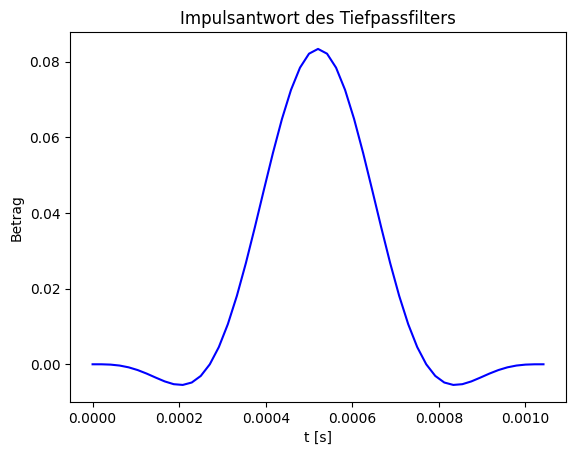

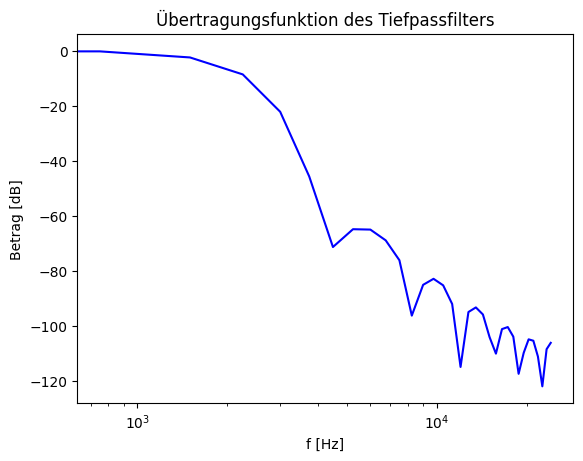

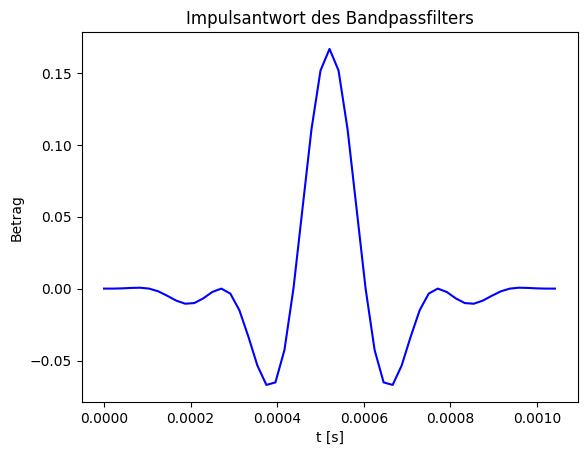

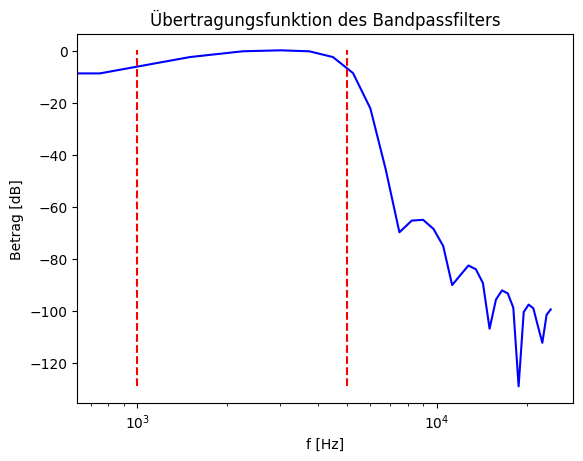

In [4]:
def ApplyFCenter(h, f_center, r):
    t = np.arange(h.shape[0]) / r
    t -= np.mean(t)
    return h * np.cos(2*np.pi*f_center*t)

def EvalImpulseResponseOFBandpassFilter(f_low, f_high, r, LengthOfFilterInSamples=501):
    assert f_high > f_low, 'die untere Frequenz muss kleiner als die obere Frequenz sein'
    assert f_high < r/2, 'Verletzung des Abtasttheorems'
    h_LP = EvalImpulseResponseOfLowpassFilter((f_high - f_low)/2, r, LengthOfFilterInSamples)
    f_center = (f_low + f_high) / 2
    return 2*ApplyFCenter(h_LP, f_center, r)

LowerCutoffFrequencyInHertz = 1000
HigherCutoffFrequencyInHertz = 5000
h_BP = EvalImpulseResponseOFBandpassFilter(LowerCutoffFrequencyInHertz, HigherCutoffFrequencyInHertz, r, 51)
t = np.arange(h_BP.shape[0]) / r
plt.plot(t, h_BP, 'b')
plt.xlabel('t [s]')
plt.ylabel('Betrag')
plt.title('Impulsantwort des Bandpassfilters')
plt.show()

FFTLength = 2**int(np.ceil(np.log2(h_BP.shape[0])))
H_BP = np.fft.rfft(h_BP, n = FFTLength)
f = np.arange(H_BP.shape[0]) / FFTLength * r
H_BP_dB = 20 * np.log10(np.abs(H_BP))
plt.semilogx(f, H_BP_dB, 'b')
plt.plot([LowerCutoffFrequencyInHertz, LowerCutoffFrequencyInHertz], [H_BP_dB.min(), H_BP_dB.max()], 'r--')
plt.plot([HigherCutoffFrequencyInHertz, HigherCutoffFrequencyInHertz], [H_BP_dB.min(), H_BP_dB.max()], 'r--')
plt.xlabel('f [Hz]')
plt.ylabel('Betrag [dB]')
plt.title('Übertragungsfunktion des Bandpassfilters')
plt.show()

## FIR: Hochpass
Jeder Tiefpass mit der Grenzfrequenz $f_{c, LP}$ kann in einen Hochpass mit der Grenzfrequenz $f_{c, HP} = \frac{r}{2} - f_{c, LP}$ umgewandelt werden:

$h_\text{highpass}(n)=h_\text{lowpass}(n) \cdot \left(-1\right)^n$

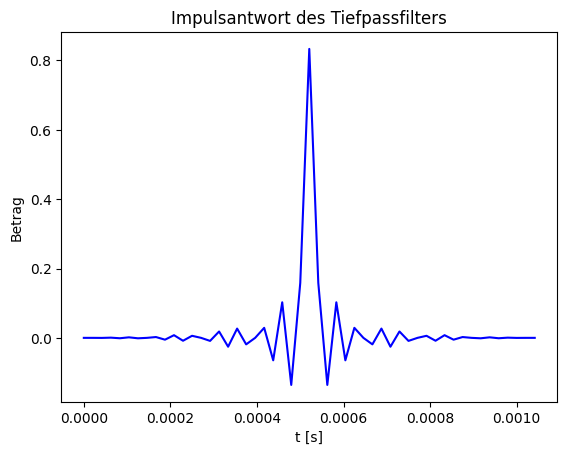

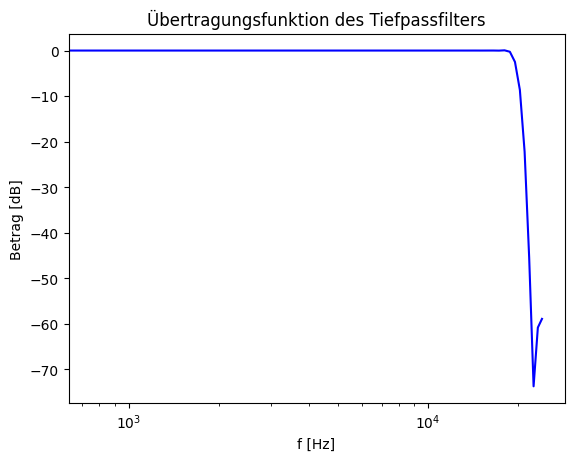

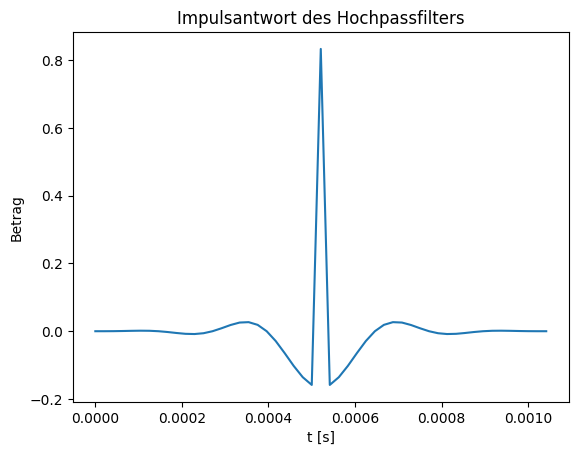

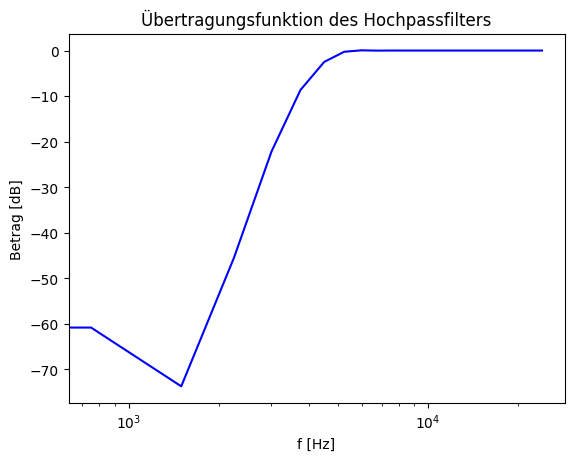

In [5]:
def EvalImpulseResponseOfHighpassFilter(fc, r, LengthOfFilterInSamples=501):
    assert fc < r/2, 'Verletzung des Abtasttheorems'
    h_LP = EvalImpulseResponseOfLowpassFilter(r/2 - fc, r, LengthOfFilterInSamples)
    f_center = r/2
    return ApplyFCenter(h_LP, f_center, r)

CutoffFrequencyInHertz = 4000
h_HP = EvalImpulseResponseOfHighpassFilter(CutoffFrequencyInHertz, r, 51)
t = np.arange(h_HP.shape[0]) / r
plt.plot(t, h_HP)
plt.xlabel('t [s]')
plt.ylabel('Betrag')
plt.title('Impulsantwort des Hochpassfilters')
plt.show()

FFTLength = 2**int(np.ceil(np.log2(h_HP.shape[0])))
H_HP = np.fft.rfft(h_HP, n = FFTLength)
f = np.arange(H_HP.shape[0]) / FFTLength * r
H_HP_dB = 20 * np.log10(np.abs(H_HP))
plt.semilogx(f, H_HP_dB, 'b')
plt.xlabel('f [Hz]')
plt.ylabel('Betrag [dB]')
plt.title('Übertragungsfunktion des Hochpassfilters')
plt.show()

## FIR-Anwendung 1: Störbehaftete Sensorsignale
Ein Sensor erfasst nicht nur das gewünschte Signal, sondern auch eine Menge Rauschen.
Der einfachste Weg, dieses Rauschen zu reduzieren, ist ein Bandpassfilter.
Um einen Bandpass zur Rauschunterdrückung einzusetzen, muss der Frequenzbereich des gewünschten Signals $x(n)$ des Sensors bekannt sein.

Im Folgenden ist das gewünschte Signal $x(n)$ ein Sweep, der von niedrigen Frequenzen bis zu den höchsten Frequenzen reicht. Dieses Signal soll ein sehr einfaches Modell der menschlichen Stimme sein.

y(n) ist das Sensorsignal, das dem gewünschten Signal plus additivem weißem gaußschen Rauschen (AWGN) entspricht.

In [6]:
f = np.arange(r)/r * 3000 + 100
t = np.arange(r)/r
x = np.sin(2*np.pi*f*t)
y = x + 0.2*np.random.randn(x.shape[0])
SNR = 10*np.log10(np.sum(x**2) / np.sum((x-y)**2))
print('SNR des Sensors: ', SNR, ' dB')

SNR des Sensors:  10.955473304300485  dB


## FIR-Anwendung 1: Entstörung durch Bandpassfilterung

Im Folgenden wird ein Bandpass definiert, der die wichtigsten Anteile der Stimme (Wideband-Stimme) durchlässt. Dieser Bandpass verursacht eine Verzögerung $D$ und eine Verstärkung $a$ bezüglich der Amplitude:

$z(n)=a\cdot y(n-D)$

Die Verzögerung $D$ eines symmetrischen Filters der Länge $N$ ist die halbe Filterlänge: $D=\frac{N}{2}$.
Ein FIR-Filter ist symmetrisch, wenn für jedes $n$ gilt: $h(n) = h(N-1-n)$.

Die beste Schätzung für die Amplitudenänderung wird durch Minimierung des quadratischen Fehlers berechnet (und damit durch Maximierung des [SNR](../Basics/SignalToNoiseRatio.ipynb)):

Minimiere bezüglich des Parameters $a$: $\sum_n \left(a\cdot y(n-D) - z(n)\right)^2$

Das Minimum liegt bei:

$a=\frac{\sum_n y\left(n-D\right)\cdot z(n)}{\sum_n y(n-D)^2}$

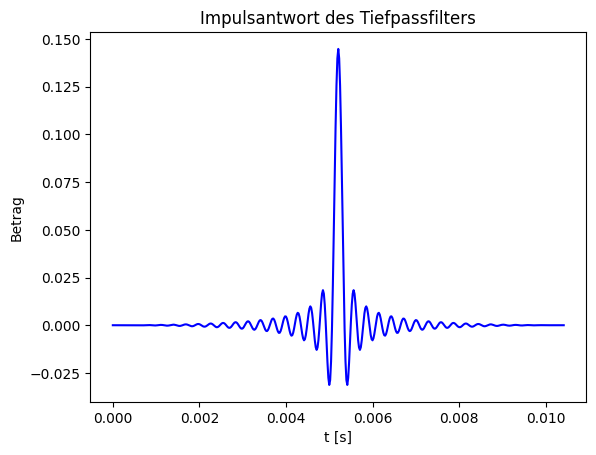

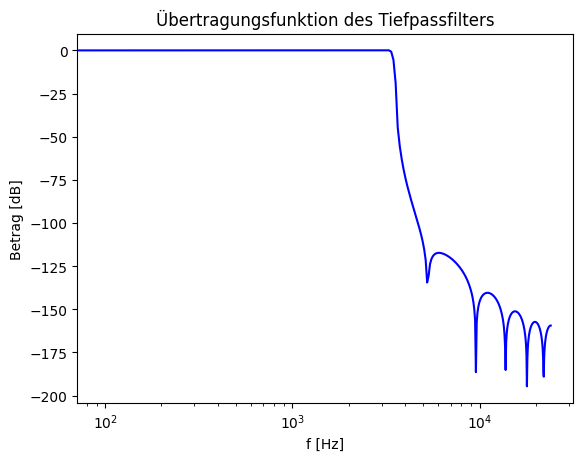

Verzögerung durch Filterung in Samples: D =  250
Verstärkung durch Filterung =  0.9456018929460172
SNR vor dem Bandpass:  10.955473304300485  dB
SNR nach dem Bandpass:  15.323210514529737  dB


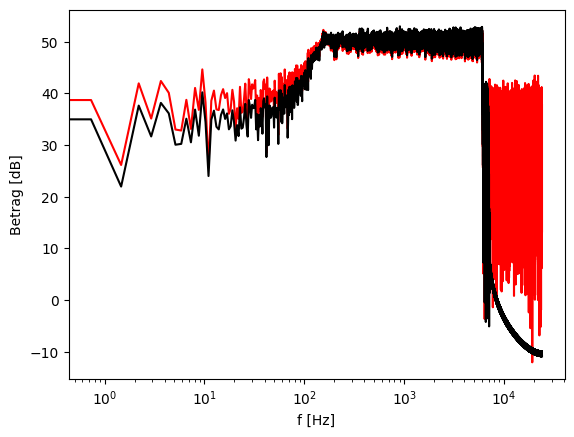

In [7]:
LowerCutoffFrequencyInHertz = 50
UpperCutoffFrequencyInHertz = 7000
N = 501
h_BP = EvalImpulseResponseOFBandpassFilter(LowerCutoffFrequencyInHertz, UpperCutoffFrequencyInHertz, r, LengthOfFilterInSamples=N)
for n in range(N):
    assert np.abs(h_BP[n] - h_BP[N-1-n]) < 1e-6, 'die Impulsantwort des Bandpassfilters sollte symmetrisch sein'
z = np.convolve(y, h_BP)
D = h_BP.shape[0] // 2
print('Verzögerung durch Filterung in Samples: D = ', D)
z = z[D:x.shape[0]+D]
a = np.sum(y*z) / np.sum(y**2)
print('Verstärkung durch Filterung = ', a)
z /= a
SNR = 10*np.log10(np.sum(x**2) / np.sum((x - y)**2))
print('SNR vor dem Bandpass: ', SNR, ' dB')
SNR = 10*np.log10(np.sum(x**2) / np.sum((x - z)**2))
print('SNR nach dem Bandpass: ', SNR, ' dB')


FFTLength = 2**int(np.ceil(np.log2(y.shape[0])))
Y = np.fft.rfft(y, n=FFTLength)
Z = np.fft.rfft(z, n=FFTLength)
Y_dB = 20 * np.log10(np.abs(Y))
Z_dB = 20 * np.log10(np.abs(Z))
f = np.arange(Y.shape[0]) / FFTLength * r
plt.semilogx(f, Y_dB, 'r') # verrauschtes Signal
plt.semilogx(f, Z_dB, 'k') # entstörtes Signal nach dem Bandpass
plt.xlabel('f [Hz]')
plt.ylabel('Betrag [dB]')
plt.show()

## FIR-Anwendung 2: Frequenzbereich der menschlichen Stimme

Die menschliche Stimme kann typischerweise in drei verschiedenen Modi aufgenommen werden:

Narrowband entspricht einem Frequenzbereich von $300 \text{ Hz}<f<3400\text{ Hz}$.

Wideband entspricht einem Frequenzbereich von $50 \text{ Hz}<f<7000\text{ Hz}$.

Fullband entspricht einem Frequenzbereich von $20 \text{ Hz}<f<20000\text{ Hz}$.

Hören Sie sich die Ausgaben an und bewerten Sie die Signale Narrowband, Wideband und Fullband hinsichtlich ihrer Qualität.

Abtastrate: r= 48000


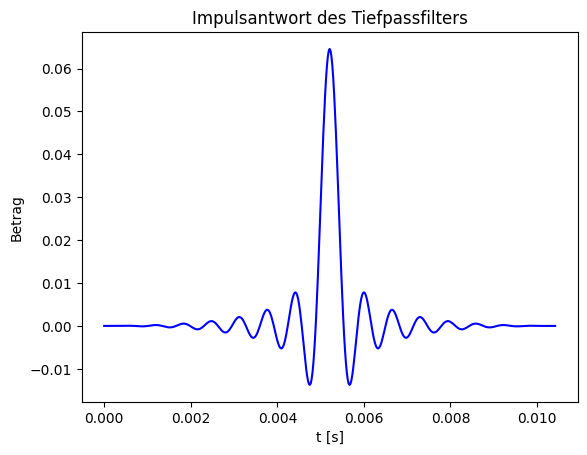

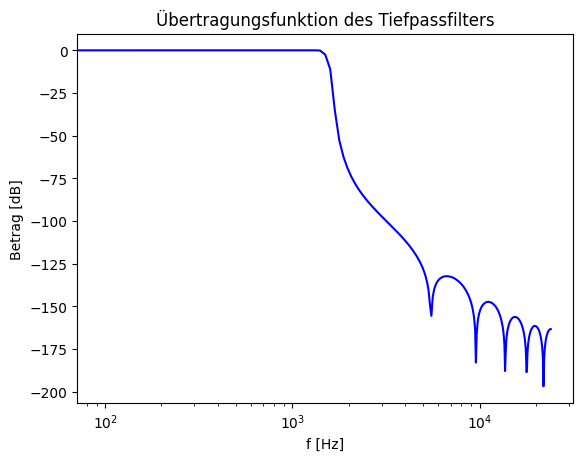

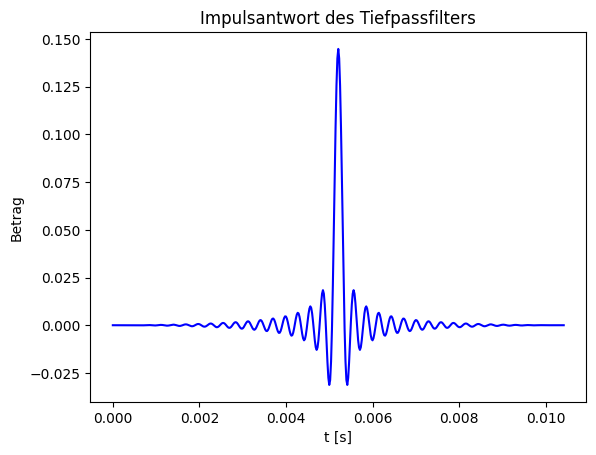

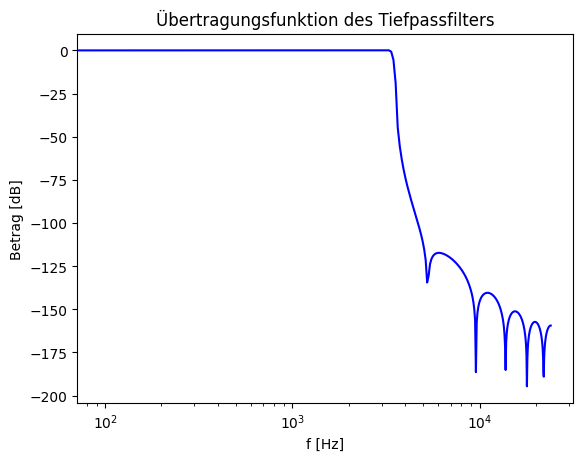

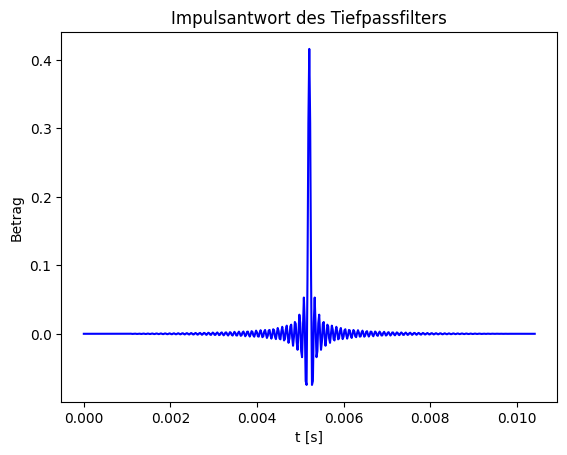

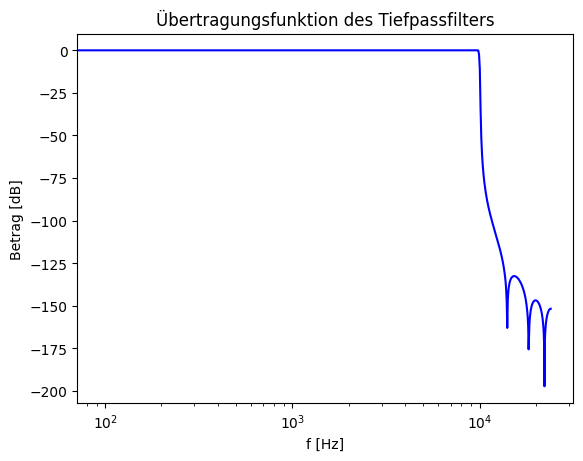

In [8]:
x, r = WaveFileHandling.ReadWaveAsNumpyArray('../Audio/P501_D_EN_fm_SWB_48k.wav')
print('Abtastrate: r=', r)

def ApplyBandpass(x, r, fc1, fc2):
    h_BP = EvalImpulseResponseOFBandpassFilter(fc1, fc2, r)
    y = np.convolve(x, h_BP)
    y /= np.amax(np.abs(y))
    return y

y_NB = ApplyBandpass(x, r, 300, 3400)
WaveFileHandling.WriteWaveAsNumpyArray(y_NB, r, 'Narrowband.wav')
y_WB = ApplyBandpass(x, r, 50, 7000)
WaveFileHandling.WriteWaveAsNumpyArray(y_WB, r, 'Wideband.wav')
y_FB = ApplyBandpass(x, r, 20, 20000)
WaveFileHandling.WriteWaveAsNumpyArray(y_FB, r, 'Fullband.wav')

## Unendlicher Impulsantwortfilter
Unendliche Impulsantwortfilter (IIR) werden durch die Differenzgleichung definiert:

$y(n) = \sum_{k=0}^K b_k\cdot x(n-k)-\sum_{l=1}^L a_l\cdot y(n-l)$

Zur Auswertung des Ausgangs $y(n)$ eines IIR-Filters sind nur $K + 1 + L$ Multiplikationen und Additionen notwendig. Der Grad des IIR-Filters ist in der Regel viel kleiner als die Länge eines FIR-Filters. Daher ist die Auswertung in der Regel deutlich schneller als bei einem FIR-Filter.

In [9]:
from scipy.signal import lfilter, butter, ellip

### dieser Filter simuliert die Übertragungsfunktion des Außenohrs (Vary, Digitale Sprachsignalverarbeitung, Seite 517)
a = np.array([1, 0.797, -0.161, -0.281, -0.111])
b = np.array([1.378, 0.574, -0.512, -0.129, -0.065])

x = np.random.randn(10000)

t0 = time.time()
y1 = np.zeros(x.shape)
for n in range(x.shape[0]):
    for k in range(b.shape[0]):
        if n-k >= 0:
            y1[n] += b[k] * x[n-k]
    for l in range(1, a.shape[0]):
        if n-l >= 0:
            y1[n] -= a[l] * y1[n-l]

t1 = time.time()

y2 = lfilter(b, a, x)

t2 = time.time()

print('langsame Auswertung: ', t1 - t0, ' s')
print('schnelle Auswertung: ', t2 - t1, ' s')
assert np.sum((y1-y2)**2) < 1e-10, 'Fehler bei der IIR-Auswertung'

ModuleNotFoundError: No module named 'scipy'

## IIR: z-Transformation der Differenzgleichung
Die zugehörige [z-Transformation](../Basics/zTransform.ipynb) der Differenzgleichung lautet:

$Y(z) = \sum_{k=0}^K b_k\cdot z^{-k}\cdot X(z)-\sum_{l=1}^L a_l\cdot z^{-l}Y(z)$

Die Übertragungsfunktion ist definiert durch:

$H(z)=\frac{Y(z)}{X(z)}=\frac{\sum_{k=0}^K b_k\cdot z^{-k}}{1+\sum_{l=1}^L a_l\cdot z^{-l}}$

Die Übertragungsfunktion im Frequenzbereich erhält man durch die folgende Ersetzung:

$z\rightarrow e^{j2\pi f / r}$

$H(f)=\frac{\sum_{k=0}^K b_k\cdot e^{-j2\pi f k/r}}{1+\sum_{l=1}^L a_l\cdot e^{-j2\pi f l/r}}$

Im folgenden Beispiel wird die Übertragungsfunktion des Filters ausgewertet. Man erkennt, dass das Maximum der Übertragungsfunktion ungefähr bei $3$ kHz liegt, mit abfallenden Flanken für höhere und niedrigere Frequenzen. Dadurch wird der gegebene Filter als Bandpass klassifiziert.

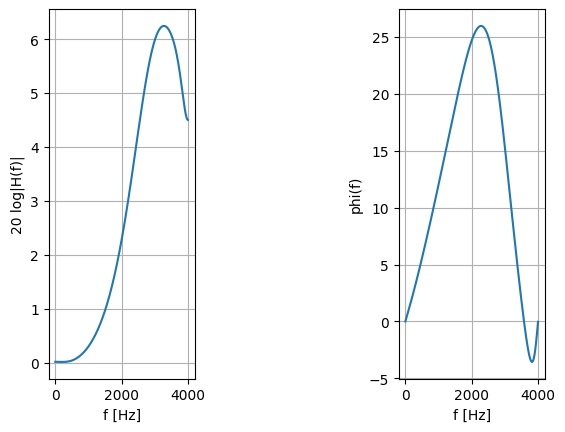

In [ ]:
def Transferfunction(a, b, z):    
    N = 0
    D = 1
    for k in range(b.shape[0]):
        N += b[k] * (z**(-k))
    for l in range(1, a.shape[0]):
        D += a[l] * (z**(-l))
    H = N / D
    return H

def BodePlotIIRFilter(a, b, r):
    f = np.arange(r/2)
    z = np.exp(1j*2*np.pi*f/r)
    H = Transferfunction(a, b, z)
    plt.subplot(131)
    plt.plot(f, 20*np.log10(np.abs(H)))
    plt.ylabel('20 log|H(f)|')
    plt.xlabel('f [Hz]')
    plt.grid(which='both', axis='both')
    plt.subplot(133)
    plt.plot(f, np.angle(H, deg=True))
    plt.ylabel('Phase $\varphi(f)$')
    plt.xlabel('f [Hz]')
    plt.grid(which='both', axis='both')
    plt.show()    

r = 8000
BodePlotIIRFilter(a, b, r)

## IIR: Stabilität, Pole, Nullstellen
Ein IIR-Filter ist stabil, wenn alle Pole von $H(z)$ innerhalb des Einheitskreises liegen:

$H(z)=\frac{\sum_{k=0}^K b_k\cdot z^{-k}}{1+\sum_{l=1}^L a_l\cdot z^{-l}}$

Die Nullstellen $z_{0,k}$ werden durch Lösen der folgenden Gleichung bestimmt:

$\sum_{k=0}^K b_k\cdot z_{0,k}^{-k} = 0$

Die Pole $z_{p,l}$ werden durch Lösen der folgenden Gleichung bestimmt:

$1+\sum_{l=1}^L a_l\cdot z_{p,l}^{-l} = 0$

Die berechneten Pole und Nullstellen werden üblicherweise in einem Pol-Nullstellen-Diagramm der komplexen Ebene dargestellt, wie unten gezeigt.

IIR filter is stable:  True


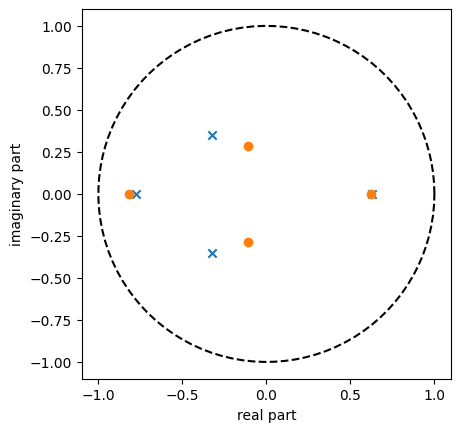

In [ ]:
def IsStableIIRFilter(a, b):
    DenominatorRoots = np.roots(a)
    return np.amax(np.abs(DenominatorRoots)) < 1.0

def PlotZerosPolesIIRFilter(a, b):
    NumeratorRoots = np.roots(b)
    DenominatorRoots = np.roots(a)
    phi = np.arange(100) / 99 * 2 * np.pi
    plt.plot(np.cos(phi), np.sin(phi), '--k') # Einheitskreis zeichnen
    plt.scatter(DenominatorRoots.real, DenominatorRoots.imag, marker = 'x') # Nullstellen zeichnen
    plt.scatter(NumeratorRoots.real, NumeratorRoots.imag, marker = 'o') # Pole zeichnen
    plt.xlabel('Realteil')
    plt.ylabel('Imaginärteil')
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.show()

print('IIR-Filter ist stabil: ', IsStableIIRFilter(a, b))
PlotZerosPolesIIRFilter(a, b)

## IIR: Flächendarstellung der Übertragungsfunktion
Wird die Übertragungsfunktion als Fläche im z-Bereich dargestellt, lassen sich Pole und Nullstellen als Stützpunkte eines Zelts interpretieren. Die Pole entsprechen in dieser Metapher den Zeltstangen. Die Nullstellen sind die Punkte, an denen das Zelt den Boden berührt. Die Übertragungsfunktion im Frequenzbereich ist der Betrag an der Position des Einheitskreises.

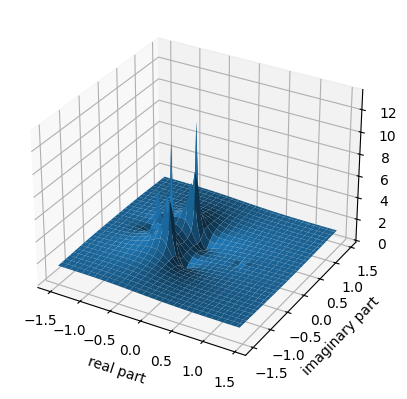

In [ ]:
def TransferFunctionSurface(x, y):
    z = x + 1j*y
    return np.abs(Transferfunction(a, b, z))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x = y = np.arange(-1.5, 1.5, 0.05)
X, Y = np.meshgrid(x, y)
zs = np.array(TransferFunctionSurface(np.ravel(X), np.ravel(Y)))
Z = zs.reshape(X.shape)

ax.plot_surface(X, Y, Z)

ax.set_xlabel('Realteil')
ax.set_ylabel('Imaginärteil')
ax.set_zlabel('Betrag')

plt.show()

## Programmieraufgabe:

Die Grenzfrequenz $f_c$ eines Tiefpasses $X(f)$ ist definiert durch:

$\frac{\left|H\left(f_c\right)\right|}{\left|H\right|_\text{max}}=\frac{1}{\sqrt{2}}$ (1)

In [Dezibel](../Basics/Decibel.ipynb) entspricht das:

$20\log_{10}\frac{1}{\sqrt{2}}=-3.01$ dB

Ein Bandpass hat zwei Grenzfrequenzen, die das Durchlassband markieren. Zur Vereinfachung werden die Grenzfrequenzen eines Bandpasses wie folgt definiert:

Die untere Grenzfrequenz ist die niedrigste Frequenz, für die Bedingung (1) wahr ist.

Die obere Grenzfrequenz ist die höchste Frequenz, für die Bedingung (1) wahr ist.

1) Schreiben Sie eine Prozedur EvaluateMagnitudeSpectrum, die die Übertragungsfunktion aus einer Impulsantwort bestimmt.

2) Schreiben Sie eine Prozedur EvaluateCutoffFrequencies, die die Grenzfrequenzen eines zeitdiskreten FIR-Bandpasses im Zeitbereich bestimmt. Verwenden Sie dazu die [DFT](../Week03_DiscreteFourierTransform/01_DiscreteFourierTransform.ipynb), um die Grenzfrequenzen mit einer Genauigkeit von $20$ Hz zu berechnen.

Die folgende Gleichung für einen IIR-Filter ist gegeben: $y(n) = a\cdot y(n-1) + (1-a)\cdot x(n)$ mit $3-\sqrt{8}<|a|<1$

3) Schreiben Sie den Code für die Prozedur TransferFunction, um die zugehörige Übertragungsfunktion $H(f)$ zu berechnen.

4) Schreiben Sie den Code für die Prozedur CheckInput1, die die Bedingungen für den Parameter $a$ überprüft.

5) Schreiben Sie den Code für die Prozedur DampingParameter2CutoffFrequency, um die Grenzfrequenz in Abhängigkeit vom Dämpfungsparameter $a$ zu berechnen. Hinweis: Die gegebene Gleichung ist ein Tiefpass mit dem größten Betrag bei $f=0$ Hz.

6) Schreiben Sie den Code für die Prozedur CheckInput2, die die Bedingungen der Grenzfrequenz und der Abtastrate überprüft.

7) Schreiben Sie den Code für die Prozedur CutoffFrequency2DampingParameter, um den Parameter $a$ in Abhängigkeit von der Grenzfrequenz zu bestimmen.

In [ ]:
def EvaluateMagnitudeSpectrum(h, r, MaximumDeltaf):
    ### solution begins

    # Berechne die benötigte FFT-Länge basierend auf der gewünschten Frequenzauflösung
    FFTLength = int(np.ceil(r / MaximumDeltaf))
    # Berechne die FFT (nur positive Frequenzen) der Impulsantwort h
    H = np.fft.rfft(h, n=FFTLength)
    # Erstelle die Frequenzachse von 0 bis r/2 Hz
    f = np.arange(H.shape[0]) / FFTLength * r
    H = np.abs(H)

    ### solution ends
    return H, f

def EvaluateCutoffFrequencies(h_Bandpass, r):
    ### solution begins

    # Verwende eine Frequenzauflösung von 20 Hz für die Grenzfrequenzberechnung
    MaximumDeltaf = 20
    # Berechne das Betragsspektrum des Bandpassfilters
    H, f = EvaluateMagnitudeSpectrum(h_Bandpass, r, MaximumDeltaf)
    # Finde das Maximum der Übertragungsfunktion
    max_H = np.max(H)
    # Definiere den Schwellenwert: 1/sqrt(2) des Maximums (≈ -3.01 dB)
    threshold = max_H / np.sqrt(2)
    # Finde alle Frequenzen, wo H >= Schwellenwert
    idx_valid = np.where(H >= threshold)[0]
    # Die untere Grenzfrequenz ist die erste Frequenz im Durchlassband
    fc1 = f[idx_valid[0]] if len(idx_valid) > 0 else 0
    # Die obere Grenzfrequenz ist die letzte Frequenz im Durchlassband
    fc2 = f[idx_valid[-1]] if len(idx_valid) > 0 else r/2

    ### solution ends
    return fc1, fc2

def TransferFunction(f, r, a):
    H = 1
    ### solution

    # Berechne z = e^(j*2*π*f/r) für Frequenzbereichsanalyse
    z = np.exp(1j * 2 * np.pi * f / r)
    # Übertragungsfunktion für y(n) = a*y(n-1) + (1-a)*x(n):
    # H(z) = (1-a) / (1 - a*z^(-1))
    H = (1 - a) / (1 - a * z**(-1))

    ### solution
    return H

def CheckInput1(a):
    ### solution

    # Überprüfe die Stabilitätsbedingung: 3-√8 < |a| < 1
    LowerLimit = 3 - np.sqrt(8)
    UpperLimit = 1.0
    assert LowerLimit < np.abs(a) < UpperLimit, f'Parameter a muss im Bereich ({LowerLimit:.6f}, {UpperLimit}) liegen'

    ### solution

def DampingParameter2CutoffFrequency(a, r):
    CheckInput1(a)
    ### solution

    # Bei Grenzfrequenz gilt: |H(fc)| = max(|H|) / √2
    # Dies führt zu: cos(2π*fc/r) = (4*a - 1 - a²) / (2*a)
    arg = (4*a - 1 - a**2) / (2*a)
    # Limitiere das Argument auf [-1, 1] um Numerikfehler zu vermeiden
    arg = np.clip(arg, -1, 1)
    # Berechne die Grenzfrequenz aus der Arkuskosinus-Beziehung
    fc = r / (2 * np.pi) * np.arccos(arg)

    ### solution
    return fc

def CheckInput2(fc, r):
    ### solution

    # Überprüfe, dass die Grenzfrequenz im gültigen Bereich liegt: 0 < fc < r/2
    assert 0 < fc < r/2, f'Grenzfrequenz muss im Bereich (0, {r/2}) liegen'

    ### solution


def CutoffFrequency2DampingParameter(fc, r):
    CheckInput2(fc, r)
    a = 0
    ### solution
    
    # Berechne cos(2π*fc/r) aus der Grenzfrequenz
    cos_val = np.cos(2 * np.pi * fc / r)
    # Umformen der Grenzfrequenzgleichung führt zu einer quadratischen Gleichung:
    # a² + a*(2*cos(2π*fc/r) - 4) + 1 = 0
    b_coeff = 2 * cos_val - 4
    c_coeff = 1
    # Berechne die Diskriminante für die quadratische Lösungsformel
    discriminant = b_coeff**2 - 4*c_coeff
    # Berechne beide Lösungen der quadratischen Gleichung
    a1 = (-b_coeff + np.sqrt(discriminant)) / 2
    a2 = (-b_coeff - np.sqrt(discriminant)) / 2
    # Wähle die Lösung, die die Stabilitätsbedingung erfüllt
    LowerLimit = 3 - np.sqrt(8)
    UpperLimit = 1.0
    if LowerLimit < a1 < UpperLimit:
        a = a1
    elif LowerLimit < a2 < UpperLimit:
        a = a2
    else:
        # Fallback: Gebe die nähere der beiden Grenzen zurück
        a = a1 if np.abs(a1 - (LowerLimit + UpperLimit)/2) < np.abs(a2 - (LowerLimit + UpperLimit)/2) else a2

    ### solution
    return a

import unittest

class TestProgrammingExercise(unittest.TestCase):

    def test_EvaluateDFT_Shape(self):
        r = 16000
        MaximumDeltaf = np.random.rand(1)*100
        MaximumDeltaf = MaximumDeltaf[0]
        h = np.array([1, -2, 1])
        H, f = EvaluateMagnitudeSpectrum(h, r, MaximumDeltaf)
        self.assertEqual(H.shape, f.shape)

    def test_EvaluateDFT_LinearityOfFrequencyAxis(self):
        r = 16000
        MaximumDeltaf = np.random.rand(1)*100
        MaximumDeltaf = MaximumDeltaf[0]
        h = np.array([1, -2, 1])
        H, f = EvaluateMagnitudeSpectrum(h, r, MaximumDeltaf)
        self.assertLessEqual(np.std(np.diff(f)), 1e-6) # check linearity of frequency axis

    def test_EvaluateDFT_ConditionDeltaf(self):
        r = 16000
        MaximumDeltaf = np.random.rand(1)*100
        MaximumDeltaf = MaximumDeltaf[0]
        h = np.array([1, -2, 1])
        H, f = EvaluateMagnitudeSpectrum(h, r, MaximumDeltaf)
        self.assertLessEqual(np.mean(np.diff(f)), MaximumDeltaf)

    def test_EvaluateDFT_MonotonicityOfFrequencyAxis(self):
        r = 16000
        MaximumDeltaf = np.random.rand(1)*100
        MaximumDeltaf = MaximumDeltaf[0]
        h = np.array([1, -2, 1])
        H, f = EvaluateMagnitudeSpectrum(h, r, MaximumDeltaf)
        self.assertGreater(np.min(np.diff(f)), 0.0) # check monotonicity of frequency axis
        self.assertGreater(np.min(np.diff(H)), 0.0) # check monotonicity of magnitude spectrum of a low-pass filter
        self.assertGreater(np.max(np.diff(H)), 0.0) # check monotonicity of magnitude spectrum of a low-pass filter

    def test_EvaluateDFT_MonotonicityOfTransferFunction(self):
        r = 16000
        MaximumDeltaf = np.random.rand(1)*100
        MaximumDeltaf = MaximumDeltaf[0]
        h = np.array([1, -2, 1])
        H, f = EvaluateMagnitudeSpectrum(h, r, MaximumDeltaf)
        self.assertGreater(np.min(np.diff(H)), 0.0) # check monotonicity of magnitude spectrum of a low-pass filter
        self.assertGreater(np.max(np.diff(H)), 0.0) # check monotonicity of magnitude spectrum of a low-pass filter
    
    def test_RandomBandpasses(self):
        r = 16000
        for n in range(10):
            fc1 = np.random.rand(1) * r/8 + r/8
            fc2 = r/2 - (np.random.rand(1) * r/8 + r/8)
            h_Bandpass = EvalImpulseResponseOFBandpassFilter(fc1, fc2, r, LengthOfFilterInSamples=5001)
            fc1_est, fc2_est = EvaluateCutoffFrequencies(h_Bandpass, r)
            self.assertAlmostEqual(fc1_est, fc1, delta = 20.0)
            self.assertAlmostEqual(fc2_est, fc2, delta = 20.0)

    def test_CheckInput1(self):
        UpperLimit = 1.0
        LowerLimit = 3-np.sqrt(8)
        a = np.random.randn(1)**2 + UpperLimit
        self.assertRaises(AssertionError, CheckInput1, a)
        a = LowerLimit - np.random.randn(1)**2
        self.assertRaises(AssertionError, CheckInput1, a)
        self.assertRaises(AssertionError, CheckInput1, UpperLimit)
        self.assertRaises(AssertionError, CheckInput1, LowerLimit)

    def test_CheckInput2(self):
        r = 16000
        fc = np.random.rand(1)*2*r-r
        if (fc <= 0.0) or (2*fc >= r):
            self.assertRaises(AssertionError, CheckInput2, fc, r)

    def test_TransferFunction(self):
        f = 1500
        r = 16000
        a = 0.75
        self.assertAlmostEqual(0.2984-0.3304j, TransferFunction(f, r, a), delta = 1e-1)
        f = 12000
        r = 32000
        a = 0.9        
        self.assertAlmostEqual(0.05308-0.02064j, TransferFunction(f, r, a), delta = 1e-1)
        f = 12000
        r = 32000
        a = -0.9        
        self.assertAlmostEqual(1.286+2.2508j, TransferFunction(f, r, a), delta = 1e-1)

    def test_DampingParameter(self):
        for r in [16000, 32000, 44100]:
            a = 0.9
            fc = DampingParameter2CutoffFrequency(a, r)
            self.assertAlmostEqual(fc, r*0.016784, delta = 1e-2)
            a = 0.7
            fc = DampingParameter2CutoffFrequency(a, r)
            self.assertAlmostEqual(fc, r*0.057378, delta = 1e-2)

    def test_CutoffFrequency1(self):
        r = 44100
        fc = r/5
        a = CutoffFrequency2DampingParameter(fc, r)
        self.assertAlmostEqual(a, 0.32737619817917585, delta = 1e-7)
        r = 16000
        fc = r/7
        a = CutoffFrequency2DampingParameter(fc, r)
        self.assertAlmostEqual(a, 0.4305819103800278, delta = 1e-7)
    
    def test_CutoffFrequency2(self):
        r = 16000
        x = 2/3
        for n in range(100):
            x = (x-x**2)*4
            assert x > 0.0, 'input too small'
            assert x < 1.0, 'input too large'
            fc = x*r/2        
            a = CutoffFrequency2DampingParameter(fc, r)
            self.assertAlmostEqual(np.abs(TransferFunction(fc, r, a)), 1/np.sqrt(2), delta = 1e-2)
            self.assertGreater(np.abs(TransferFunction((0 + fc) * 0.5, r, a)), 1/np.sqrt(2))
            self.assertLess(np.abs(TransferFunction((r/2 + fc) * 0.5, r, a)), 1/np.sqrt(2))

    def test_RandomInversion(self):
        r = 48000
        x = 2/3
        for n in range(100):
            x = (x-x**2)*4
            assert x > 0.0, 'input too small'
            assert x < 1.0, 'input too large'
            fc = x*r/2
            a = CutoffFrequency2DampingParameter(fc, r)
            self.assertAlmostEqual(fc, DampingParameter2CutoffFrequency(a, r), delta = 1e-1)
    
# https://stackoverflow.com/questions/40172281/unit-tests-for-functions-in-a-jupyter-notebook
unittest.main(argv=[''], verbosity=2, exit=False)

test_CheckInput1 (__main__.TestProgrammingExercise.test_CheckInput1) ... ok
test_CheckInput2 (__main__.TestProgrammingExercise.test_CheckInput2) ... ok
test_CutoffFrequency1 (__main__.TestProgrammingExercise.test_CutoffFrequency1) ... ok
test_CutoffFrequency2 (__main__.TestProgrammingExercise.test_CutoffFrequency2) ... ok
test_DampingParameter (__main__.TestProgrammingExercise.test_DampingParameter) ... ok
test_EvaluateDFT_ConditionDeltaf (__main__.TestProgrammingExercise.test_EvaluateDFT_ConditionDeltaf) ... ok
test_EvaluateDFT_LinearityOfFrequencyAxis (__main__.TestProgrammingExercise.test_EvaluateDFT_LinearityOfFrequencyAxis) ... ok
test_EvaluateDFT_MonotonicityOfFrequencyAxis (__main__.TestProgrammingExercise.test_EvaluateDFT_MonotonicityOfFrequencyAxis) ... ok
test_EvaluateDFT_MonotonicityOfTransferFunction (__main__.TestProgrammingExercise.test_EvaluateDFT_MonotonicityOfTransferFunction) ... ok
test_EvaluateDFT_Shape (__main__.TestProgrammingExercise.test_EvaluateDFT_Shape) ... o

## Prüfungsvorbereitung

1) Bestimmen Sie die [z-Transformation](../Basics/zTransform.ipynb) eines Filters $h(n)=[1, 2, 1]$. Ist dieser Filter ein Tiefpass, ein Bandpass oder ein Hochpass? Hinweis: Zur einfacheren Auswertung wird $r=1$ angenommen.

2) Wandeln Sie den FIR-Filter $h(n)=[1, 2, 1]$ in einen Hochpass um.

3) Bestimmen Sie die Faltung von $x(n) = [0, 1, 2]$ mit $h(n)=[1, 2, 1]$.

4) Bestimmen Sie die Abtastwerte der Impulsantwort eines FIR-Tiefpasses der Länge $N=5$ für eine Abtastrate von $r=1000$ Hz und eine Grenzfrequenz von $f_c = 250$ Hz.

5) Wie viele Multiplikationen und Additionen sind erforderlich, um einen einzelnen Ausgabewert eines FIR-Filters mit der Länge $N=501$ abzutasten.

6) Zeigen Sie, dass $a=\frac{\sum_n y\left(n-T\right)\cdot z(n)}{\sum_n y(n-T)^2}$ das Minimum von $\sum_n \left(a\cdot y(n-T) - z(n)\right)^2$ liefert.

7) Weißes Hintergrundrauschen hat näherungsweise ein konstantes Leistungsdichtespektrum $\left|R(f)\right|^2\approx \text{const}$. Bestimmen Sie die SNR-Steigerung durch einen idealen FIR-Bandpass mit den Grenzfrequenzen $f_{c1}=100$ Hz und $f_{c2}=7000$ Hz, unter der Annahme, dass die menschliche Stimme diesen Filter ohne Qualitätsverlust durchlaufen kann. Die Abtastrate wird mit $r=48$ kHz angenommen.

8) Ein FIR-Tiefpass ist gegeben: $h(n)=[a,1,a]$ mit reellwertigem $a$. Für welches $a$ gilt die folgende Bedingung? $\left|H(f)\right| > 0$

9) Ein FIR-Filter ist gegeben: $ℎ(𝑛)=[-1, 1]$. Ist $ℎ(𝑛)$ stabil? (Begründen Sie Ihre Antwort.) Bestimmen Sie den Realteil der Übertragungsfunktion $𝐻(𝑓)$ von $ℎ(𝑛)$. Ist der Realteil für irgendein $𝑓$ positiv?

10) Ein Tiefpass ist gegeben durch $h(n)=[1, 4, 6, 4, 1]$. Die Abtastrate beträgt $r=48$ kHz. Bestimmen Sie die Impulsantwort des zugehörigen Bandpasses mit $f_m=12$ kHz.

11) Für welches $a$ ist die folgende Gleichung $y(n) = a\cdot y(n-1) + (1-a)\cdot x(n)$ stabil?

12) Bestimmen Sie die Grenzfrequenz $f_c$ des IIR-Filters aus 11) in Abhängigkeit vom Dämpfungsparameter $a$.

13) Der Filter aus 11) besitzt die Impulsantwort $h(n) = (1-a) \cdot a^n$. Bestimmen Sie das kleinstmögliche $n_0$, für das folgende Aussage gilt: $h(n_0) < h(n=0)\cdot e^{-5}$. Dieses $n_0$ kann als sinnvolle Länge der Impulsantwort interpretiert werden. Für $n > n_0$ kann die Impulsantwort als stationär interpretiert werden.

14) Ein Audio-Interface hat eine Abtastrate von $r=48$ kHz. Zur Entstörung wird das Signal mit einem Bandpass mit den Grenzfrequenzen $f_{c,1}=100$ Hz und $f_{c,2}=7$ kHz gefiltert. Hat das Audiosignal nach dem Filter einen Mittelwert von null? Kann menschliche Sprache diesen Filter passieren? Würde dieser Filter Brummstörungen bei $50$ Hz unterdrücken?

15) Bestimmen Sie die Pole und Nullstellen von $H(z)=\frac{z^2-4z-7}{z^2-9}$.

## Lösungen zur Prüfungsvorbereitung (ausführlich erklärt)

### 1) z-Transformation von $h(n)=[1,2,1]$

**Gegeben:**
$$h(0)=1,\; h(1)=2,\; h(2)=1$$

Die z-Transformation eines FIR-Filters lautet allgemein:
$$H(z)=\sum_{n=0}^{N-1} h(n)z^{-n}$$

Damit ergibt sich:
$$H(z)=1+2z^{-1}+z^{-2}=(1+z^{-1})^2$$

Zur Filterklassifikation betrachtet man den Frequenzgang auf dem Einheitskreis $z=e^{j\omega}$:
- Bei $\omega=0$ (DC): $H(e^{j0})=1+2+1=4$ (maximal)
- Bei $\omega=\pi$ (Nyquist): $H(e^{j\pi})=1-2+1=0$ (minimal)

**Interpretation:** tiefe Frequenzen werden stark durchgelassen, hohe unterdrückt.

**=> Tiefpass**

---

### 2) FIR-Tiefpass in Hochpass umwandeln

Ein Spektrum kann um $\pi$ verschoben werden durch Multiplikation der Impulsantwort mit $(-1)^n$:
$$h_{HP}(n)=h(n)\cdot(-1)^n$$

Für $h(n)=[1,2,1]$ folgt:
$$h_{HP}(n)=[1,-2,1]$$

Prüfung:
- Bei $\omega=0$: $1-2+1=0$
- Bei $\omega=\pi$: $1+2+1=4$

**=> Hochpass**

---

### 3) Faltung von $x(n)=[0,1,2]$ mit $h(n)=[1,2,1]$

Allgemein:
$$y(n)=(x*h)(n)=\sum_k x(k)h(n-k)$$

Die Ergebnislänge ist:
$$N_y=N_x+N_h-1=3+3-1=5$$

Einzelschritte:
- $y(0)=0\cdot1=0$
- $y(1)=0\cdot2+1\cdot1=1$
- $y(2)=0\cdot1+1\cdot2+2\cdot1=4$
- $y(3)=1\cdot1+2\cdot2=5$
- $y(4)=2\cdot1=2$

Damit:
$$y(n)=[0,1,4,5,2]$$

---

### 4) Impulsantwort eines FIR-Tiefpasses ($N=5$, $r=1000$ Hz, $f_c=250$ Hz)

Idealer (unendlicher) Tiefpass:
$$h_d(n)=\begin{cases}
\dfrac{\sin\left(2\pi f_c n/r\right)}{\pi n}, & n\neq 0\\[4pt]
\dfrac{2f_c}{r}, & n=0
\end{cases}$$

Hier ist:
$$h(0)=\frac{2f_c}{r}=\frac{2\cdot 250}{1000}=0.5$$

Für einen FIR-Filter endlicher Länge wird üblicherweise ein Fenster verwendet (z. B. Hann), um Nebenkeulen zu reduzieren.

---

### 5) Rechenaufwand für FIR mit $N=501$

Ein FIR-Ausgabewert:
$$y(n)=\sum_{m=0}^{N-1} h(m)x(n-m)$$

Pro Ausgabesample braucht man:
- $N=501$ Multiplikationen
- $N-1=500$ Additionen

**Gesamt: 1001 Grundoperationen pro Sample**

---

### 6) Nachweis der optimalen Skalierung

Zu minimieren:
$$E(a)=\sum_n\left(a\,y(n-T)-z(n)\right)^2$$

Ableitung nach $a$ und Nullsetzen:
$$\frac{dE}{da}=2\sum_n\left(a\,y(n-T)-z(n)\right)y(n-T)=0$$

Umstellen:
$$a\sum_n y(n-T)^2=\sum_n y(n-T)z(n)$$

Damit:
$$a=\frac{\sum_n y(n-T)z(n)}{\sum_n y(n-T)^2}$$

Da die zweite Ableitung
$$\frac{d^2E}{da^2}=2\sum_n y(n-T)^2>0$$
ist, liegt ein **Minimum** vor.

---

### 7) SNR-Steigerung durch idealen Bandpass

Gegeben:
- $f_{c1}=100$ Hz
- $f_{c2}=7000$ Hz
- $r=48$ kHz $\Rightarrow f_N=r/2=24000$ Hz

Durchgelassene Bandbreite:
$$\Delta f_{BP}=7000-100=6900\text{ Hz}$$

Bei weißem Rauschen ist die Rauschleistung proportional zur Bandbreite. Daher:
$$G_{SNR}=10\log_{10}\left(\frac{24000}{6900}\right)\approx 5.4\text{ dB}$$

**=> theoretischer SNR-Gewinn ca. 5.4 dB**

---

### 8) Bedingung für $|H(f)|>0$ bei $h(n)=[a,1,a]$

$$H(e^{j\omega})=a+e^{-j\omega}+ae^{-j2\omega}=e^{-j\omega}\left(1+2a\cos\omega\right)$$

Da $|e^{-j\omega}|=1$, folgt:
$$|H(e^{j\omega})|=|1+2a\cos\omega|$$

Damit $|H(f)|>0$ für **alle** $\omega$, muss gelten:
$$1+2a\cos\omega\neq 0\quad \forall\,\omega$$

Da $\cos\omega\in[-1,1]$, ist die kritische Bedingung:
$$|2a|<1\;\Leftrightarrow\; |a|<0.5$$

**=> Für streng positives Spektrum überall: $-0.5<a<0.5$**

---

### 9) FIR-Filter $h(n)=[-1,1]$: Stabilität und Realteil

$$H(z)=-1+z^{-1}$$

Mit $z=e^{j\omega}$:
$$H(e^{j\omega})=-1+e^{-j\omega}$$

Realteil:
$$\Re\{H(e^{j\omega})\}=-1+\cos\omega\le 0$$

Ein FIR-Filter besitzt endliche Impulsantwort und ist daher BIBO-stabil.

**=> stabil, Realteil nie positiv**

---

### 10) Bandpass aus Tiefpass $h(n)=[1,4,6,4,1]$ mit $f_m=12$ kHz

Bandpasserzeugung durch Modulation:
$$h_{BP}(n)=h_{LP}(n)\cos\left(2\pi\frac{f_m}{r}n\right)$$

Mit $f_m/r=12000/48000=1/4$:
$$\cos\left(2\pi\frac{1}{4}n\right)=\cos\left(\frac{\pi}{2}n\right)$$

Die Kosinusfolge lautet (für aufeinanderfolgende $n$):
$$[\ldots,0,-1,0,1,0,-1,\ldots]$$

Man multipliziert jeden Tiefpass-Koeffizienten mit dem passenden Kosinuswert.

---

### 11) Stabilität von
$$y(n)=a\,y(n-1)+(1-a)x(n)$$

z-Transformierte (Ruheanfangsbedingungen):
$$Y(z)=az^{-1}Y(z)+(1-a)X(z)$$
$$H(z)=\frac{Y(z)}{X(z)}=\frac{1-a}{1-az^{-1}}$$

Pol bei $z=a$. Für BIBO-Stabilität muss der Pol im Einheitskreis liegen:
$$|a|<1$$

**=> stabil für $-1<a<1$**

---

### 12) Grenzfrequenz des IIR-Filters aus 11)

Aus
$$H(e^{j\omega})=\frac{1-a}{1-ae^{-j\omega}}$$
folgt
$$|H(e^{j\omega})|^2=\frac{(1-a)^2}{1+a^2-2a\cos\omega}$$

Die -3-dB-Grenze ist
$$|H(e^{j\omega_c})|^2=\frac{1}{2}|H(0)|^2$$
(bei diesem Filter ist $|H(0)|=1$)

Daraus:
$$\cos\omega_c=\frac{4a-1-a^2}{2a}$$

mit $\omega_c=2\pi f_c/r$ ergibt:
$$f_c=\frac{r}{2\pi}\arccos\left(\frac{4a-1-a^2}{2a}\right)$$

---

### 13) Effektive Impulsantwortlänge bei
$$h(n)=(1-a)a^n$$

Gesucht ist kleinstes $n_0$ mit
$$h(n_0)<h(0)e^{-5}$$

Einsetzen:
$$(1-a)a^{n_0}<(1-a)e^{-5}\Rightarrow a^{n_0}<e^{-5}$$

Für $0<a<1$:
$$n_0>\frac{-5}{\ln a}$$

Also sinnvoll:
$$n_0=\left\lceil\frac{-5}{\ln a}\right\rceil$$

Beispiel $a=0.9$:
$$n_0=\left\lceil\frac{-5}{\ln(0.9)}\right\rceil=48$$

---

### 14) Bandpass 100 Hz - 7 kHz bei $r=48$ kHz

1. **Mittelwert nach Filterung:**
Ein idealer Bandpass unterdrückt DC ($f=0$), daher geht der Gleichanteil gegen 0.

2. **Sprache passierbar?**
Ja, der Bereich 100 Hz bis 7 kHz deckt Sprachverständlichkeit sehr gut ab.

3. **50-Hz-Brummen:**
50 Hz liegt unterhalb der unteren Grenzfrequenz 100 Hz und wird daher gedämpft.

---

### 15) Pole und Nullstellen von
$$H(z)=\frac{z^2-4z-7}{z^2-9}$$

**Nullstellen:**
$$z^2-4z-7=0\Rightarrow z=2\pm\sqrt{11}$$

Näherungen:
$$z_1\approx 5.32,\quad z_2\approx -1.32$$

**Pole:**
$$z^2-9=0\Rightarrow z=\pm 3$$

Da beide Pole außerhalb des Einheitskreises liegen ($|z|>1$):

**=> als kausales LTI-System nicht BIBO-stabil**

## Zusammenfassung
Nach der Arbeit mit diesem Jupyter-Notebook sollten Sie die folgenden Themen erklären können:

- Wie lautet die Gleichung zur Berechnung des Ausgangs eines FIR-Filters?
- Woran erkennt man, ob ein Filter ein Tiefpass, ein Bandpass oder ein Hochpass ist?
- Was ist die Motivation für den Einsatz eines Bandpasses auf dem Sensorsignal?
- Wie kann man die Verzögerung eines symmetrischen FIR-Filters bestimmen?
- Wie kann man erkennen, ob ein FIR-Filter symmetrisch ist?
- Wie kann man die Verstärkung eines Filters bestimmen?
- Welcher Frequenzbereich gilt für menschliche Sprache?
- Wie kann man einen Tiefpass in einen Bandpass oder in einen Hochpass umwandeln?
- Wie lautet der Zusammenhang zwischen Differenzialgleichung und Übertragungsfunktion eines IIR-Filters?
- Wie lautet der Zusammenhang zwischen z-Transformation und Fourier-Transformation bei einem IIR-Filter?
- Wie kann man das Pol-Nullstellen-Diagramm auswerten?
- Unter welchen Umständen ist ein IIR-Filter stabil?

## Zusammenfassung (ausführlich erklärt)

Nach der Arbeit mit diesem Jupyter-Notebook sollten Sie die folgenden Themen **nicht nur benennen**, sondern auch **rechnerisch anwenden und begründen** können.

### 1) Gleichung zur Berechnung des Ausgangs eines FIR-Filters

Ein FIR-Filter bildet den aktuellen Ausgabewert als gewichtete Summe aktueller und vergangener Eingangswerte:

$$
y(n)=\sum_{k=0}^{N-1} h(k)\,x(n-k)
$$

- $h(k)$ sind die Filterkoeffizienten (Impulsantwort)
- $N$ ist die Filterlänge
- Das Filter besitzt keine Rückkopplung auf frühere Ausgabewerte

Interpretation: Jeder Eingangswert wird mit einem Gewicht multipliziert und alle Beiträge werden addiert.

### 2) Erkennen von Tiefpass, Bandpass oder Hochpass

Entscheidend ist der Frequenzgang $|H(f)|$:

- **Tiefpass**: hohe Verstärkung bei kleinen Frequenzen, schwach bei hohen
- **Hochpass**: niedrige Verstärkung bei kleinen Frequenzen, hoch bei großen
- **Bandpass**: nur ein mittlerer Frequenzbereich wird gut durchgelassen

Praktisch prüft man oft Werte bei $f=0$ (DC) und bei $f=r/2$ (Nyquist).

### 3) Motivation für einen Bandpass auf dem Sensorsignal

Ein Bandpass unterdrückt:
- sehr tiefe Störungen (z. B. Drift, DC, Netzbrummen im unteren Bereich)
- sehr hohe Störungen (z. B. Rauschen, HF-Anteile)

Damit bleibt der relevante Signalbereich erhalten. Ergebnis: bessere Signalqualität und häufig bessere Erkennung/Analyse.

### 4) Verzögerung eines symmetrischen FIR-Filters

Bei linearphasigem symmetrischem FIR gilt die Gruppenlaufzeit:

$$
\tau_g=\frac{N-1}{2}
$$

in Samples. In Sekunden:

$$
T_g=\frac{N-1}{2r}
$$

mit Abtastrate $r$. Diese Verzögerung ist für alle Frequenzen gleich (keine Phasenverzerrung).

### 5) Erkennen, ob ein FIR-Filter symmetrisch ist

Symmetriebedingung:

$$
h(k)=h(N-1-k)
$$

Beispiel: $[1,4,6,4,1]$ ist symmetrisch.

Folge: linearphasiges Verhalten und konstante Gruppenlaufzeit.

### 6) Verstärkung eines Filters bestimmen

Die frequenzabhängige Verstärkung ist:

$$
|H(f)|
$$

In dB:

$$
G_{dB}(f)=20\log_{10}|H(f)|
$$

Wichtige Spezialfälle:
- **DC-Verstärkung** bei $f=0$
- **Passbandverstärkung** im Durchlassbereich
- **Sperrbanddämpfung** im unterdrückten Bereich

### 7) Frequenzbereich menschlicher Sprache

Typische Orientierungswerte:
- Grundfrequenzen: grob etwa 80 bis 300 Hz (sprecherabhängig)
- Für gute Verständlichkeit relevante Anteile: ungefähr bis 7 kHz

Darum wird häufig ein Band wie 100 Hz bis 7 kHz für Sprachanwendungen verwendet.

### 8) Tiefpass in Bandpass oder Hochpass umwandeln

- **Tiefpass zu Hochpass**: Modulation mit $(-1)^n$ (Spektralverschiebung um $\pi$)
- **Tiefpass zu Bandpass**: Modulation mit Kosinus

$$
h_{BP}(n)=h_{LP}(n)\cos\left(2\pi\frac{f_m}{r}n\right)
$$

Dabei verschiebt $f_m$ das Spektrum in den gewünschten Mittenfrequenzbereich.

### 9) Zusammenhang zwischen Differenzialgleichung und Übertragungsfunktion (IIR)

Allgemeine Differenzengleichung:

$$
y(n)=\sum_{m=1}^{M}a_m y(n-m)+\sum_{k=0}^{K}b_k x(n-k)
$$

Nach z-Transformation folgt:

$$
H(z)=\frac{Y(z)}{X(z)}=\frac{\sum_{k=0}^{K}b_k z^{-k}}{1-\sum_{m=1}^{M}a_m z^{-m}}
$$

Die Rückkopplungstherme ($a_m$) erzeugen Pole und damit IIR-Verhalten.

### 10) Zusammenhang zwischen z-Transformation und Fourier-Transformation

Die z-Transformation ist allgemeiner:

$$
H(z)\quad\text{mit komplexem }z
$$

Der Frequenzgang ergibt sich als Spezialfall auf dem Einheitskreis:

$$
H(f)=H(z)\big|_{z=e^{j2\pi f/r}}
$$

Also: Fourier-Darstellung = Auswertung der z-Darstellung auf $|z|=1$.

### 11) Pol-Nullstellen-Diagramm auswerten

- **Nullstellen**: Frequenzen/Anteile werden abgeschwächt oder ausgelöscht
- **Pole**: beeinflussen Resonanz, Verstärkung und Dynamik stark
- Nähe von Pol/Nullstelle zum Einheitskreis bestimmt die Stärke des Effekts

Merksatz: Je näher ein Pol am Einheitskreis, desto schmalbandiger und ausgeprägter die Resonanz.

### 12) Wann ist ein IIR-Filter stabil?

Für ein kausales diskretes LTI-System gilt BIBO-Stabilität genau dann, wenn **alle Pole innerhalb des Einheitskreises** liegen:

$$
|p_i|<1\quad\forall i
$$

Liegt mindestens ein Pol auf oder außerhalb des Einheitskreises, ist das System nicht BIBO-stabil.

---

### Lernziel in einem Satz

Sie sollten Filter nun so analysieren können, dass Sie aus Koeffizienten oder Gleichungen direkt auf **Filtertyp, Verzögerung, Verstärkung, Stabilität und praktische Eignung für Sprachsignale** schließen können.